# Notebook 21: Clinical & Biomedical Imaging — Data Modalities

**BINF 4002 — Machine Learning for Health** | Lecture 21 Companion

---

## Overview

This notebook uses **real medical images** from multiple sources to generate lecture figures. The primary data sources are:

| Source | Modality | What you get |
|--------|----------|-------------|
| **MedMNIST** (download) | Chest X-ray, Dermoscopy, H&E Pathology | Standardized 28×28–224×224 benchmark images with labels |
| **pydicom** (bundled) | CT, MRI | Real DICOM files with full clinical metadata |
| **scikit-image** (bundled) | Retinal fundus, IHC tissue, microscopy | High-res bundled images |

**Important notes on data realism:**
- MedMNIST images are real clinical images but downsampled (originals are much larger). They are the best freely downloadable option for this notebook.
- The pydicom CT/MRI are small test files (128×128 / 64×64), not full clinical volumes (512×512×300+).
- The scikit-image IHC tissue uses immunohistochemistry stain, which is visually distinct from H&E (the clinical standard). We use PathMNIST for true H&E examples when available.
- The Shepp-Logan phantom in the windowing demo is a synthetic mathematical test object, not a real CT scan.

**If MedMNIST download fails:** The notebook falls back to bundled data only, but some figures will be less representative. See the "Extending" section at the end for manual download instructions.

In [ ]:
!pip -qq install pydicom medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.7 MB/s eta 0:00:00


In [ ]:
# ==============================================================================
# Imports & Setup
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import os

FIGURE_DIR = "./figures/"
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs("./medmnist_data", exist_ok=True)

import skimage.data
from skimage.transform import resize
from skimage.color import rgb2gray

import pydicom

# Try MedMNIST
try:
    import medmnist
    from medmnist import ChestMNIST, DermaMNIST, PathMNIST
    HAS_MEDMNIST = True
    print(f"medmnist {medmnist.__version__} available")
except ImportError:
    HAS_MEDMNIST = False
    print("medmnist not installed. Install with: pip install medmnist")

print(f"scikit-image {__import__('skimage').__version__}")
print(f"pydicom {pydicom.__version__}")
print(f"Figures → {os.path.abspath(FIGURE_DIR)}")

medmnist 3.0.2 available
scikit-image 0.25.2
pydicom 3.0.2
Figures → /content/figures


In [ ]:
# ==============================================================================
# Load MedMNIST Data (Chest X-Ray, Dermoscopy, H&E Pathology)
# ==============================================================================
MEDMNIST_LOADED = False

if HAS_MEDMNIST:
    try:
        print("Downloading MedMNIST datasets (first run only)...")
        chest_ds = ChestMNIST(split='test', download=True, size=224, root='./medmnist_data')
        derma_ds = DermaMNIST(split='test', download=True, size=224, root='./medmnist_data')
        path_ds  = PathMNIST(split='test', download=True, size=224, root='./medmnist_data')

        # Extract numpy arrays: MedMNIST returns PIL images
        def extract_images(dataset, n=50):
            imgs = []
            for i in range(min(n, len(dataset))):
                img, label = dataset[i]
                imgs.append(np.array(img))
            return np.array(imgs)

        chest_images = extract_images(chest_ds, 50)  # Grayscale chest X-rays
        derma_images = extract_images(derma_ds, 50)  # RGB dermoscopy
        path_images  = extract_images(path_ds, 50)   # RGB H&E pathology

        # Also get labels for chest X-rays
        chest_labels = np.array([chest_ds[i][1] for i in range(min(200, len(chest_ds)))])

        print(f"  ChestMNIST: {chest_images.shape} (chest X-rays, {'grayscale' if chest_images.ndim==3 else 'RGB'})")
        print(f"  DermaMNIST: {derma_images.shape} (dermoscopy)")
        print(f"  PathMNIST:  {path_images.shape} (H&E pathology)")
        print(f"  Chest labels: {chest_labels.shape}")
        MEDMNIST_LOADED = True
    except Exception as e:
        print(f"MedMNIST download failed: {e}")
        print("Falling back to bundled data only.")
        print("To fix: download .npz files manually from https://zenodo.org/records/10519652")
        print("and place them in ./medmnist_data/")

if not MEDMNIST_LOADED:
    print("\nUsing bundled data only (no chest X-ray, dermoscopy, or H&E pathology).")
    print("MedMNIST would provide these — see 'Extending' section at end.")
    chest_images = None
    derma_images = None
    path_images = None
    chest_labels = None

100%|██████████| 3.89G/3.89G [29:43<00:00, 2.18MB/s]
100%|██████████| 1.09G/1.09G [04:46<00:00, 3.81MB/s]
100%|██████████| 12.6G/12.6G [07:47<00:00, 27.0MB/s]


  ChestMNIST: (50, 224, 224) (chest X-rays, grayscale)
  DermaMNIST: (50, 224, 224, 3) (dermoscopy)
  PathMNIST:  (50, 224, 224, 3) (H&E pathology)
  Chest labels: (200, 14)


In [ ]:
# ==============================================================================
# Load Bundled Data (always available)
# ==============================================================================

# --- scikit-image bundled ---
retina_img = skimage.data.retina()          # (1411, 1411, 3) real fundoscopy
ihc_img = skimage.data.immunohistochemistry()  # (512, 512, 3) real IHC tissue
phantom = skimage.data.shepp_logan_phantom()   # (400, 400) synthetic CT test phantom
cell_img = skimage.data.cell()              # (660, 550) real fluorescence microscopy
natural_imgs = {
    "Astronaut": skimage.data.astronaut(),
    "Coffee": skimage.data.coffee(),
    "Cat": skimage.data.cat(),
}
print("scikit-image bundled data loaded.")

# --- pydicom test DICOM ---
dcm_dir = os.path.join(os.path.dirname(pydicom.__file__), "data", "test_files")
ct_dcm = pydicom.dcmread(os.path.join(dcm_dir, "CT_small.dcm"))
mr_dcm = pydicom.dcmread(os.path.join(dcm_dir, "MR_small.dcm"))
ct_pixels = ct_dcm.pixel_array.astype(np.float64)
mr_pixels = mr_dcm.pixel_array.astype(np.float64)
print(f"CT DICOM: {ct_pixels.shape}, Manufacturer: {ct_dcm.Manufacturer}")
print(f"MR DICOM: {mr_pixels.shape}, Manufacturer: {mr_dcm.Manufacturer}")
print("Note: These are small test DICOMs. Real clinical CT is 512×512×300+.")

print("\nAll data loaded.")

scikit-image bundled data loaded.
CT DICOM: (128, 128), Manufacturer: GE MEDICAL SYSTEMS
MR DICOM: (64, 64), Manufacturer: TOSHIBA_MEC
Note: These are small test DICOMs. Real clinical CT is 512×512×300+.

All data loaded.


---

## Individual Modality Examples (for slides)

Save individual example images for slide inclusion via `\includegraphics`.

In [ ]:
# Save individual modality example images for slides
print("Saving individual modality examples...")

if MEDMNIST_LOADED:
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    cxr = chest_images[0]
    ax.imshow(cxr[:,:,0] if cxr.ndim == 3 else cxr, cmap="gray")
    ax.set_title("Chest X-Ray (ChestMNIST)", fontweight='bold')
    ax.axis("off"); plt.tight_layout()
    plt.savefig(f"{FIGURE_DIR}example_xray.png", bbox_inches="tight", dpi=150); plt.close()

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(ct_pixels, cmap="gray")
ax.set_title("CT Slice (pydicom)", fontweight='bold')
ax.axis("off"); plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}example_ct.png", bbox_inches="tight", dpi=150); plt.close()

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(mr_pixels, cmap="gray")
ax.set_title("MRI Slice (pydicom)", fontweight='bold')
ax.axis("off"); plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}example_mri.png", bbox_inches="tight", dpi=150); plt.close()

h, w = retina_img.shape[:2]; crop=512; cy,cx = h//2, w//2
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(retina_img[cy-crop//2:cy+crop//2, cx-crop//2:cx+crop//2])
ax.set_title("Retinal Fundus", fontweight='bold')
ax.axis("off"); plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}example_retinal.png", bbox_inches="tight", dpi=150); plt.close()

if MEDMNIST_LOADED:
    for name, imgs in [("derm", derma_images), ("pathology", path_images)]:
        fig, ax = plt.subplots(1, 1, figsize=(4, 4))
        ax.imshow(imgs[0]); ax.axis("off"); plt.tight_layout()
        plt.savefig(f"{FIGURE_DIR}example_{name}.png", bbox_inches="tight", dpi=150); plt.close()

print("Done. Use \\includegraphics{figures/example_*.png} in slides.")

Saving individual modality examples...
Done. Use \includegraphics{figures/example_*.png} in slides.


---

## Figure 1: Visual Survey — Medical Images Across Modalities

**LECTURE FIGURE** (slides: "Real Medical Images Across Modalities")

Side-by-side comparison of real images from each modality. If MedMNIST loaded, you'll see actual chest X-rays, dermoscopy, and H&E pathology alongside CT, MRI, retinal, and natural images.

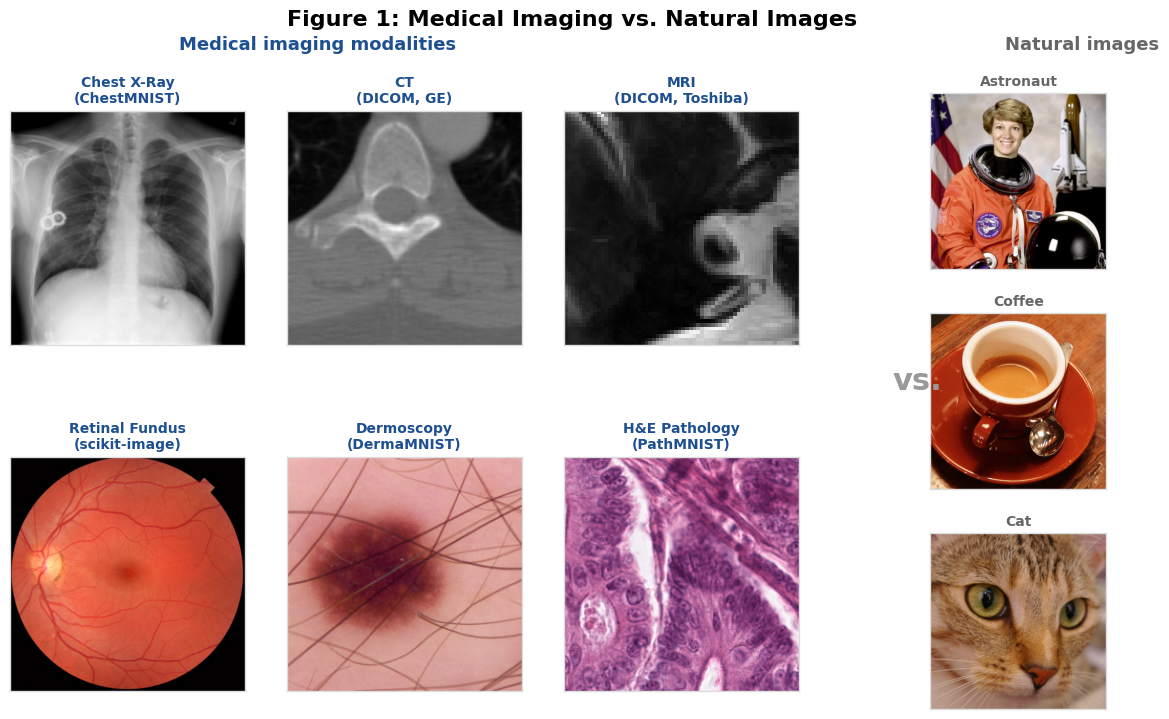

Saved fig1_visual_survey.* (with MedMNIST)


In [ ]:
# Figure 1: Medical vs Natural images — clearer side-by-side comparison
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# -----------------------------
# Assemble images
# -----------------------------
if MEDMNIST_LOADED:
    medical_imgs = [
        ("Chest X-Ray\n(ChestMNIST)", chest_images[0], "gray"),
        ("CT\n(DICOM, GE)", ct_pixels, "gray"),
        ("MRI\n(DICOM, Toshiba)", mr_pixels, "gray"),
        ("Retinal Fundus\n(scikit-image)", retina_img, None),
        ("Dermoscopy\n(DermaMNIST)", derma_images[0], None),
        ("H&E Pathology\n(PathMNIST)", path_images[0], None),
    ]
else:
    medical_imgs = [
        ("CT\n(DICOM, GE)", ct_pixels, "gray"),
        ("MRI\n(DICOM, Toshiba)", mr_pixels, "gray"),
        ("Retinal Fundus", retina_img, None),
        ("IHC Tissue\n(NOT H&E)", ihc_img, None),
        ("Cell Microscopy", cell_img, "gray"),
        ("Shepp-Logan\n(synthetic)", phantom, "gray"),
    ]

# Use all three bundled natural images so the comparison actually reads as a category
natural_imgs_list = [
    ("Astronaut", natural_imgs["Astronaut"], None),
    ("Coffee", natural_imgs["Coffee"], None),
    ("Cat", natural_imgs["Cat"], None),
]

# -----------------------------
# Helper for display
# -----------------------------
def prepare_for_display(img, cmap=None, crop_square=True):
    arr = np.asarray(img)

    # squeeze singleton channel
    if arr.ndim == 3 and arr.shape[-1] == 1:
        arr = arr[:, :, 0]

    # grayscale MedMNIST sometimes comes as 3 identical channels
    if cmap == "gray" and arr.ndim == 3:
        arr = arr[:, :, 0]

    # center-crop very non-square images so the grid looks intentional
    if crop_square:
        h, w = arr.shape[:2]
        if max(h, w) / min(h, w) > 1.2:
            side = min(h, w)
            y0 = (h - side) // 2
            x0 = (w - side) // 2
            arr = arr[y0:y0+side, x0:x0+side]

    return arr

def draw_panel(ax, title, img, cmap, title_color):
    arr = prepare_for_display(img, cmap=cmap, crop_square=True)
    if arr.ndim == 2:
        ax.imshow(arr, cmap=cmap or "gray")
    else:
        ax.imshow(arr)
    ax.set_title(title, fontsize=10, fontweight="bold", color=title_color, pad=6)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_edgecolor("#DDDDDD")

# -----------------------------
# Layout
# -----------------------------
fig = plt.figure(figsize=(15, 8), constrained_layout=False)
outer = gridspec.GridSpec(
    1, 2, figure=fig,
    width_ratios=[3.2, 1.25],
    wspace=0.12
)

medical_gs = gridspec.GridSpecFromSubplotSpec(
    2, 3, subplot_spec=outer[0],
    hspace=0.28, wspace=0.18
)

natural_gs = gridspec.GridSpecFromSubplotSpec(
    3, 1, subplot_spec=outer[1],
    hspace=0.25
)

# Left: 6 medical panels
for i, (title, img, cmap) in enumerate(medical_imgs):
    ax = fig.add_subplot(medical_gs[i // 3, i % 3])
    draw_panel(ax, title, img, cmap, title_color="#1D4F91")

# Right: 3 natural panels
for i, (title, img, cmap) in enumerate(natural_imgs_list):
    ax = fig.add_subplot(natural_gs[i, 0])
    draw_panel(ax, title, img, cmap, title_color="#666666")

# -----------------------------
# Titles / annotations
# -----------------------------
status = "with MedMNIST" if MEDMNIST_LOADED else "bundled only"

fig.suptitle(
    "Figure 1: Medical Imaging vs. Natural Images",
    fontsize=16, fontweight="bold", y=0.985
)

fig.text(
    0.33, 0.935, "Medical imaging modalities",
    fontsize=13, fontweight="bold", color="#1D4F91", ha="center"
)
fig.text(
    0.84, 0.935, "Natural images",
    fontsize=13, fontweight="bold", color="#666666", ha="center"
)
fig.text(
    0.73, 0.52, "vs.",
    fontsize=22, fontweight="bold", color="#999999", ha="center", va="center"
)

plt.savefig(f"{FIGURE_DIR}fig1_visual_survey.pdf", bbox_inches="tight", dpi=150)
plt.savefig(f"{FIGURE_DIR}fig1_visual_survey.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"Saved fig1_visual_survey.* ({status})")

---

## Figure 2: Pixel Intensity Distributions

**LECTURE FIGURE** (appendix; see notebook for interactive exploration)

Each modality has a characteristic intensity distribution.

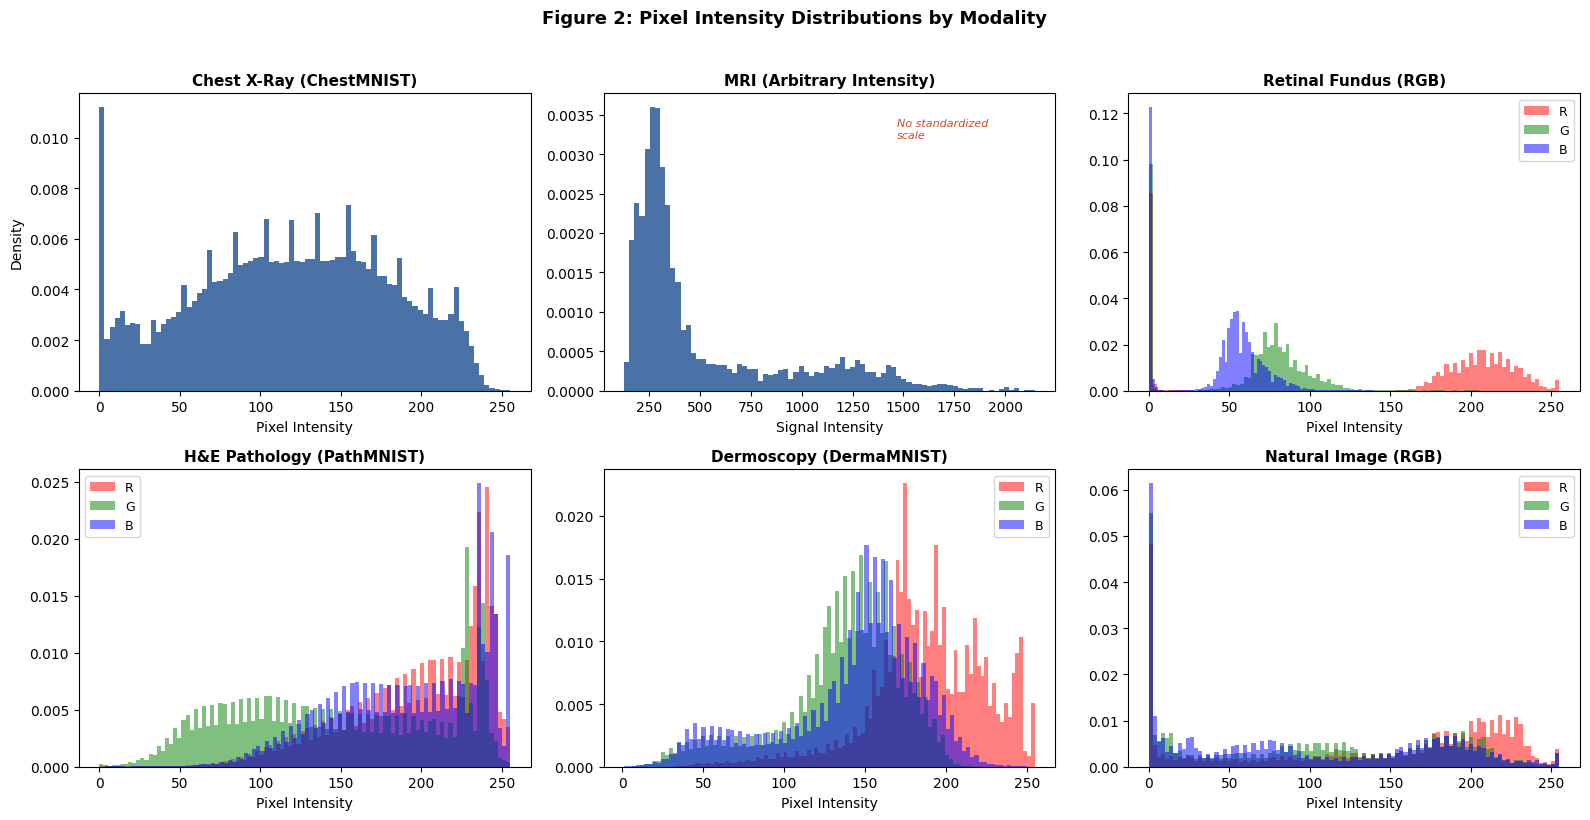

In [ ]:
n_panels = 6 if MEDMNIST_LOADED else 4
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Panel 1: Chest X-ray or CT
ax = axes[0, 0]
if MEDMNIST_LOADED:
    # Chest X-rays — may be RGB (3-channel grayscale) or actual grayscale
    cxr = chest_images[:20]
    if cxr.ndim == 4 and cxr.shape[-1] == 3:
        cxr_gray = cxr[:,:,:,0]  # All channels identical for grayscale
    else:
        cxr_gray = cxr
    ax.hist(cxr_gray.flatten(), bins=80, color="#1D4F91", alpha=0.8, density=True)
    ax.set_title("Chest X-Ray (ChestMNIST)", fontsize=11, fontweight='bold')
else:
    ax.hist(ct_pixels.flatten(), bins=80, color="#1D4F91", alpha=0.8, density=True)
    ax.set_title("CT (Hounsfield Units)", fontsize=11, fontweight='bold')
ax.set_xlabel("Pixel Intensity")
ax.set_ylabel("Density")

# Panel 2: MRI
ax = axes[0, 1]
ax.hist(mr_pixels.flatten(), bins=80, color="#1D4F91", alpha=0.8, density=True)
ax.set_title("MRI (Arbitrary Intensity)", fontsize=11, fontweight='bold')
ax.set_xlabel("Signal Intensity")
ax.annotate("No standardized\nscale", xy=(0.65, 0.85), xycoords='axes fraction',
            fontsize=8, fontstyle='italic', color='#D2492A')

# Panel 3: Retinal fundus
ax = axes[0, 2]
for c, (color, label) in enumerate(zip(["red", "green", "blue"], ["R", "G", "B"])):
    ax.hist(retina_img[:,:,c].flatten(), bins=100, color=color,
            alpha=0.5, density=True, label=label)
ax.set_title("Retinal Fundus (RGB)", fontsize=11, fontweight='bold')
ax.set_xlabel("Pixel Intensity")
ax.legend(fontsize=9)

# Panel 4: Pathology
ax = axes[1, 0]
if MEDMNIST_LOADED:
    path_sample = path_images[:20]
    for c, (color, label) in enumerate(zip(["red", "green", "blue"], ["R", "G", "B"])):
        ax.hist(path_sample[:,:,:,c].flatten(), bins=100, color=color,
                alpha=0.5, density=True, label=label)
    ax.set_title("H&E Pathology (PathMNIST)", fontsize=11, fontweight='bold')
else:
    for c, (color, label) in enumerate(zip(["red", "green", "blue"], ["R", "G", "B"])):
        ax.hist(ihc_img[:,:,c].flatten(), bins=100, color=color,
                alpha=0.5, density=True, label=label)
    ax.set_title("IHC Tissue (NOT H&E)", fontsize=11, fontweight='bold')
ax.set_xlabel("Pixel Intensity")
ax.legend(fontsize=9)

# Panel 5: Dermoscopy or Cell
ax = axes[1, 1]
if MEDMNIST_LOADED:
    derma_sample = derma_images[:20]
    for c, (color, label) in enumerate(zip(["red", "green", "blue"], ["R", "G", "B"])):
        ax.hist(derma_sample[:,:,:,c].flatten(), bins=100, color=color,
                alpha=0.5, density=True, label=label)
    ax.set_title("Dermoscopy (DermaMNIST)", fontsize=11, fontweight='bold')
else:
    ax.hist(cell_img.flatten(), bins=100, color="#2E8B57", alpha=0.8, density=True)
    ax.set_title("Cell Microscopy", fontsize=11, fontweight='bold')
ax.set_xlabel("Pixel Intensity")
if MEDMNIST_LOADED:
    ax.legend(fontsize=9)

# Panel 6: Natural
ax = axes[1, 2]
natural = natural_imgs["Astronaut"]
for c, (color, label) in enumerate(zip(["red", "green", "blue"], ["R", "G", "B"])):
    ax.hist(natural[:,:,c].flatten(), bins=100, color=color,
            alpha=0.5, density=True, label=label)
ax.set_title("Natural Image (RGB)", fontsize=11, fontweight='bold')
ax.set_xlabel("Pixel Intensity")
ax.legend(fontsize=9)

plt.suptitle("Figure 2: Pixel Intensity Distributions by Modality",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}fig2_intensity_distributions.pdf", bbox_inches="tight", dpi=150)
plt.savefig(f"{FIGURE_DIR}fig2_intensity_distributions.png", bbox_inches="tight", dpi=150)
plt.show()

---

## Figure 3: Frequency Domain Analysis (Appendix)

Radially averaged PSD for each modality. Medical images have more low-frequency energy than natural images.

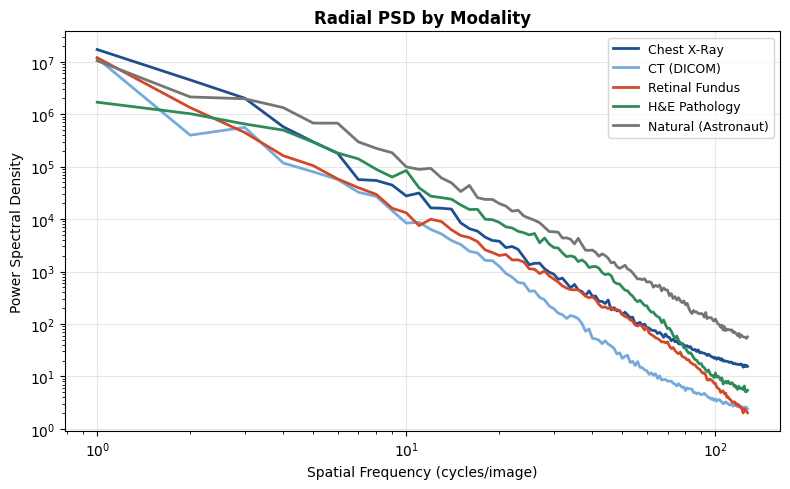

In [17]:
def compute_radial_psd(image_2d):
    f_shift = np.fft.fftshift(np.fft.fft2(image_2d))
    magnitude = np.abs(f_shift)**2
    h, w = magnitude.shape
    cy, cx = h // 2, w // 2
    Y, X = np.ogrid[:h, :w]
    R = np.sqrt((X - cx)**2 + (Y - cy)**2).astype(int)
    max_r = min(cy, cx)
    radial_psd = np.zeros(max_r)
    for r in range(max_r):
        mask = R == r
        if mask.sum() > 0:
            radial_psd[r] = magnitude[mask].mean()
    return radial_psd

def to_gray_256(img):
    if img.ndim == 3:
        gray = rgb2gray(img)
    else:
        gray = img.astype(np.float64)
        if gray.max() > 1.0:
            gray = gray / gray.max()
    return resize(gray, (256, 256), anti_aliasing=True)

# Build modality dict
psd_images = {}
if MEDMNIST_LOADED:
    cxr0 = chest_images[0]
    if cxr0.ndim == 3:
        cxr0 = cxr0[:,:,0]
    psd_images["Chest X-Ray"] = to_gray_256(cxr0)
psd_images["CT (DICOM)"] = to_gray_256(ct_pixels)
psd_images["Retinal Fundus"] = to_gray_256(retina_img)
if MEDMNIST_LOADED:
    psd_images["H&E Pathology"] = to_gray_256(path_images[0])
else:
    psd_images["IHC Tissue"] = to_gray_256(ihc_img)
psd_images["Natural (Astronaut)"] = to_gray_256(natural_imgs["Astronaut"])

colors = {"Chest X-Ray": "#1D4F91", "CT (DICOM)": "#75AAdb",
          "Retinal Fundus": "#D2492A", "H&E Pathology": "#2E8B57",
          "IHC Tissue": "#2E8B57", "Natural (Astronaut)": "#757575"}

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for name, img in psd_images.items():
    psd = compute_radial_psd(img)
    freqs = np.arange(len(psd))
    ax.loglog(freqs[1:], psd[1:], label=name, color=colors.get(name, "#333"), linewidth=2)

ax.set_xlabel("Spatial Frequency (cycles/image)")
ax.set_ylabel("Power Spectral Density")
ax.set_title("Radial PSD by Modality", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}fig3_frequency_analysis.pdf", bbox_inches="tight", dpi=150)
plt.savefig(f"{FIGURE_DIR}fig3_frequency_analysis.png", bbox_inches="tight", dpi=150)
plt.show()

---

## Figure 4: Augmentation Validity

**LECTURE FIGURE** (slide: "Augmentation Validity: What's Safe?")

Demonstrated on a real retinal fundus image.

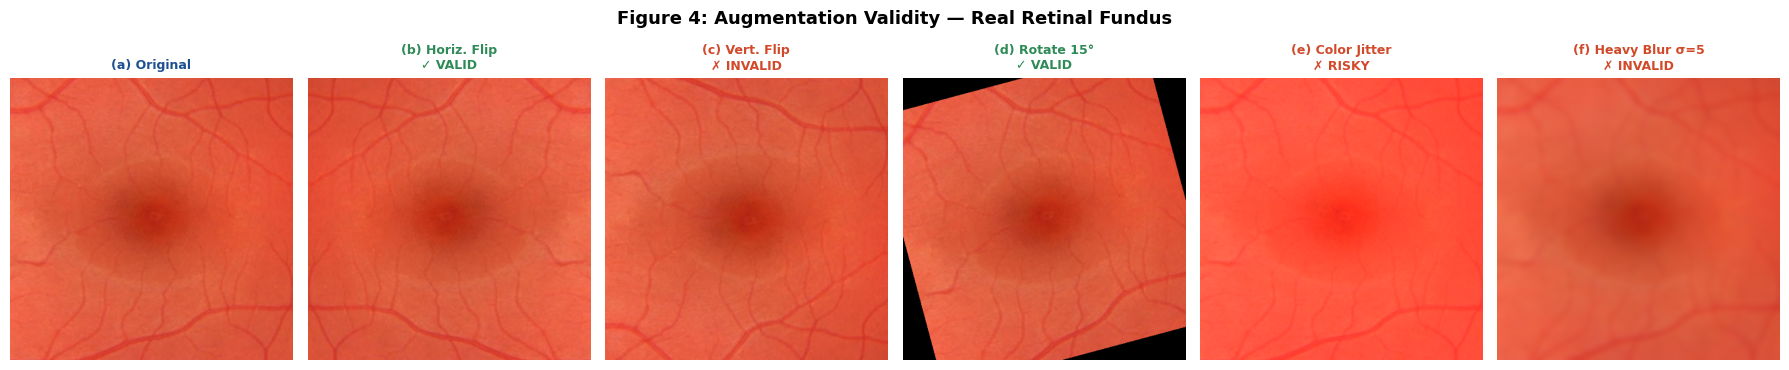

In [18]:
from scipy.ndimage import rotate as ndimage_rotate, gaussian_filter

h, w = retina_img.shape[:2]
crop_size = 512
cy, cx = h // 2, w // 2
retina_crop = retina_img[cy-crop_size//2:cy+crop_size//2, cx-crop_size//2:cx+crop_size//2].copy()
retina_float = retina_crop.astype(np.float64) / 255.0

augmentations = {
    "(a) Original": retina_float,
    "(b) Horiz. Flip\n✓ VALID": np.fliplr(retina_float),
    "(c) Vert. Flip\n✗ INVALID": np.flipud(retina_float),
    "(d) Rotate 15°\n✓ VALID": ndimage_rotate(retina_float, 15, reshape=False, mode="constant", cval=0),
    "(e) Color Jitter\n✗ RISKY": np.clip(retina_float * np.array([1.3, 0.8, 0.8]) + 0.05, 0, 1),
    "(f) Heavy Blur σ=5\n✗ INVALID": gaussian_filter(retina_float, sigma=(5, 5, 0)),
}

fig, axes = plt.subplots(1, 6, figsize=(18, 3.5))
for ax, (title, img) in zip(axes, augmentations.items()):
    ax.imshow(np.clip(img, 0, 1))
    valid = "✓" in title
    invalid = "✗" in title
    color = "#2E8B57" if valid else "#D2492A" if invalid else "#1D4F91"
    ax.set_title(title, fontsize=9, color=color, fontweight="bold")
    ax.axis("off")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(color)
        spine.set_linewidth(2)

plt.suptitle("Figure 4: Augmentation Validity — Real Retinal Fundus",
             fontsize=13, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}fig4_augmentation_validity.pdf", bbox_inches="tight", dpi=150)
plt.savefig(f"{FIGURE_DIR}fig4_augmentation_validity.png", bbox_inches="tight", dpi=150)
plt.show()

---

## Figure 5: Multi-Scale Visualization

**LECTURE FIGURE** (slide: "Multi-Scale: Real IHC Tissue")

If MedMNIST loaded, we show H&E pathology at multiple simulated magnifications. Otherwise, IHC tissue is used as a stand-in. Note: IHC (immunohistochemistry) uses antibody-based staining and is visually distinct from H&E (hematoxylin & eosin), which is the clinical standard.

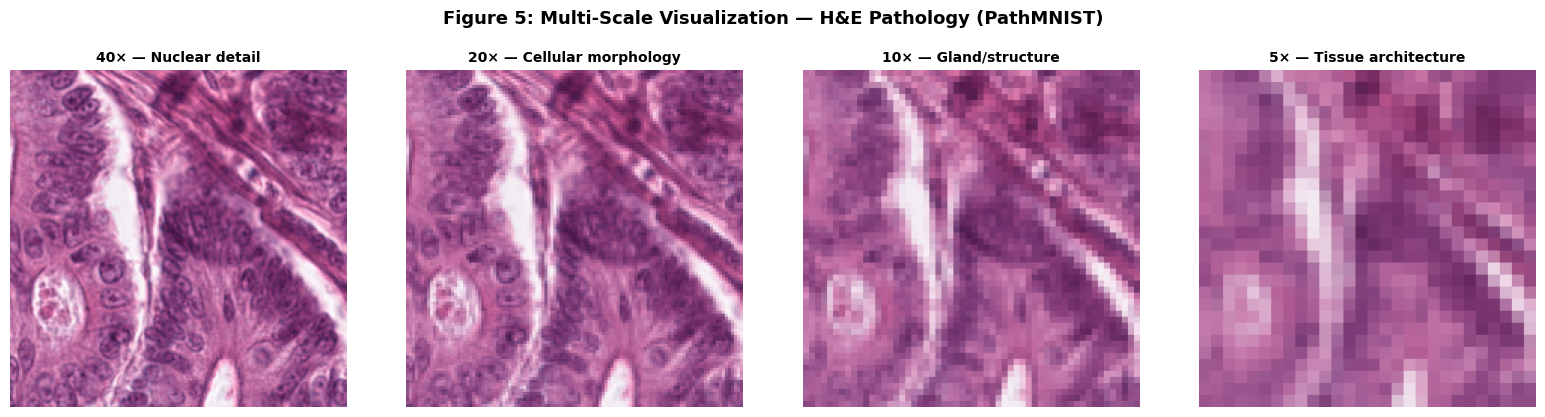

In [ ]:
if MEDMNIST_LOADED:
    tile_full = path_images[0]
    stain_label = "H&E Pathology (PathMNIST)"
else:
    tile_full = ihc_img
    stain_label = "IHC Tissue (scikit-image, NOT H&E)"

def downsample_and_display(img, factor, target_size=None):
    if target_size is None:
        target_size = img.shape[0]
    small = resize(img, (img.shape[0]//factor, img.shape[1]//factor), anti_aliasing=True)
    return resize(small, (target_size, target_size), order=0, anti_aliasing=False)

target = tile_full.shape[0]
scales = [
    (f"40× — Nuclear detail", tile_full),
    (f"20× — Cellular morphology", downsample_and_display(tile_full, 2, target)),
    (f"10× — Gland/structure", downsample_and_display(tile_full, 4, target)),
    (f"5× — Tissue architecture", downsample_and_display(tile_full, 8, target)),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (title, img) in zip(axes, scales):
    ax.imshow(img)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.axis("off")

plt.suptitle(f"Figure 5: Multi-Scale Visualization — {stain_label}",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}fig5_multiscale_pathology.pdf", bbox_inches="tight", dpi=150)
plt.savefig(f"{FIGURE_DIR}fig5_multiscale_pathology.png", bbox_inches="tight", dpi=150)
plt.show()

---

## Figure 6: DICOM Metadata Comparison

**LECTURE FIGURE** (slides: "DICOM: The Universal Standard", "Real DICOM Metadata Comparison")

Real DICOM files + windowing demo on the Shepp-Logan phantom (a synthetic mathematical test object with values mapped to a HU-like range for demonstration).

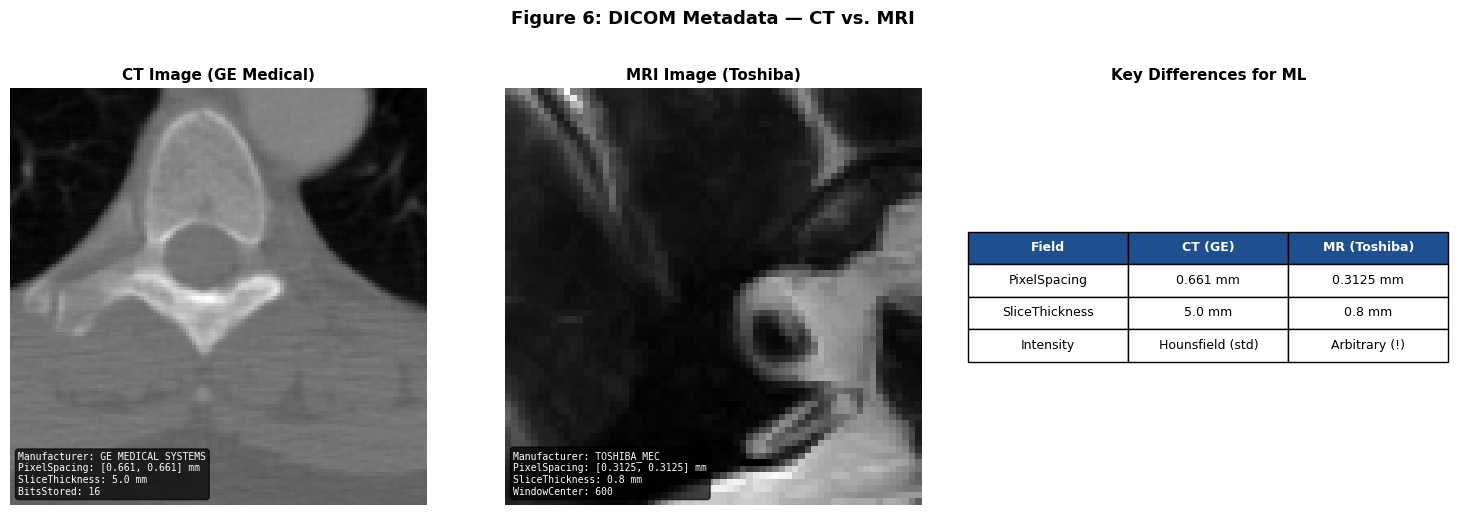

In [19]:
# Figure 6: DICOM Metadata Comparison (separate from windowing)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
ax.imshow(ct_pixels, cmap="gray")
ax.set_title("CT Image (GE Medical)", fontsize=11, fontweight="bold")
ax.axis("off")
meta = (f"Manufacturer: {ct_dcm.Manufacturer}\n"
        f"PixelSpacing: {[round(float(x),3) for x in ct_dcm.PixelSpacing]} mm\n"
        f"SliceThickness: {float(ct_dcm.SliceThickness)} mm\n"
        f"BitsStored: {ct_dcm.BitsStored}")
ax.text(0.02, 0.02, meta, transform=ax.transAxes, fontsize=7, va='bottom',
        fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='black', alpha=0.7), color='white')

ax = axes[1]
ax.imshow(mr_pixels, cmap="gray")
ax.set_title("MRI Image (Toshiba)", fontsize=11, fontweight="bold")
ax.axis("off")
meta = (f"Manufacturer: {mr_dcm.Manufacturer}\n"
        f"PixelSpacing: {[round(float(x),4) for x in mr_dcm.PixelSpacing]} mm\n"
        f"SliceThickness: {float(mr_dcm.SliceThickness)} mm\n"
        f"WindowCenter: {mr_dcm.WindowCenter}")
ax.text(0.02, 0.02, meta, transform=ax.transAxes, fontsize=7, va='bottom',
        fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='black', alpha=0.7), color='white')

ax = axes[2]
ax.axis("off")
ax.set_title("Key Differences for ML", fontsize=11, fontweight="bold")
table_data = [
    ["Field", "CT (GE)", "MR (Toshiba)"],
    ["PixelSpacing", f"{float(ct_dcm.PixelSpacing[0]):.3f} mm", f"{float(mr_dcm.PixelSpacing[0]):.4f} mm"],
    ["SliceThickness", f"{float(ct_dcm.SliceThickness):.1f} mm", f"{float(mr_dcm.SliceThickness):.1f} mm"],
    ["Intensity", "Hounsfield (std)", "Arbitrary (!)"],
]
table = ax.table(cellText=table_data, loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1.0, 1.8)
for j in range(3):
    table[0, j].set_facecolor('#1D4F91')
    table[0, j].set_text_props(color='white', fontweight='bold')

plt.suptitle("Figure 6: DICOM Metadata — CT vs. MRI", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}fig6_dicom_metadata.pdf", bbox_inches="tight", dpi=150)
plt.savefig(f"{FIGURE_DIR}fig6_dicom_metadata.png", bbox_inches="tight", dpi=150)
plt.show()

---

## Figure 8: CT Windowing Demo

**LECTURE FIGURE** (slide: "CT: Windowing Matters")

W (width) and L (level/center) define which Hounsfield unit range maps to the display. L sets the center; W sets how wide. Everything outside clips to black or white.

Applied to both the real pydicom CT and the Shepp-Logan phantom (synthetic test object).

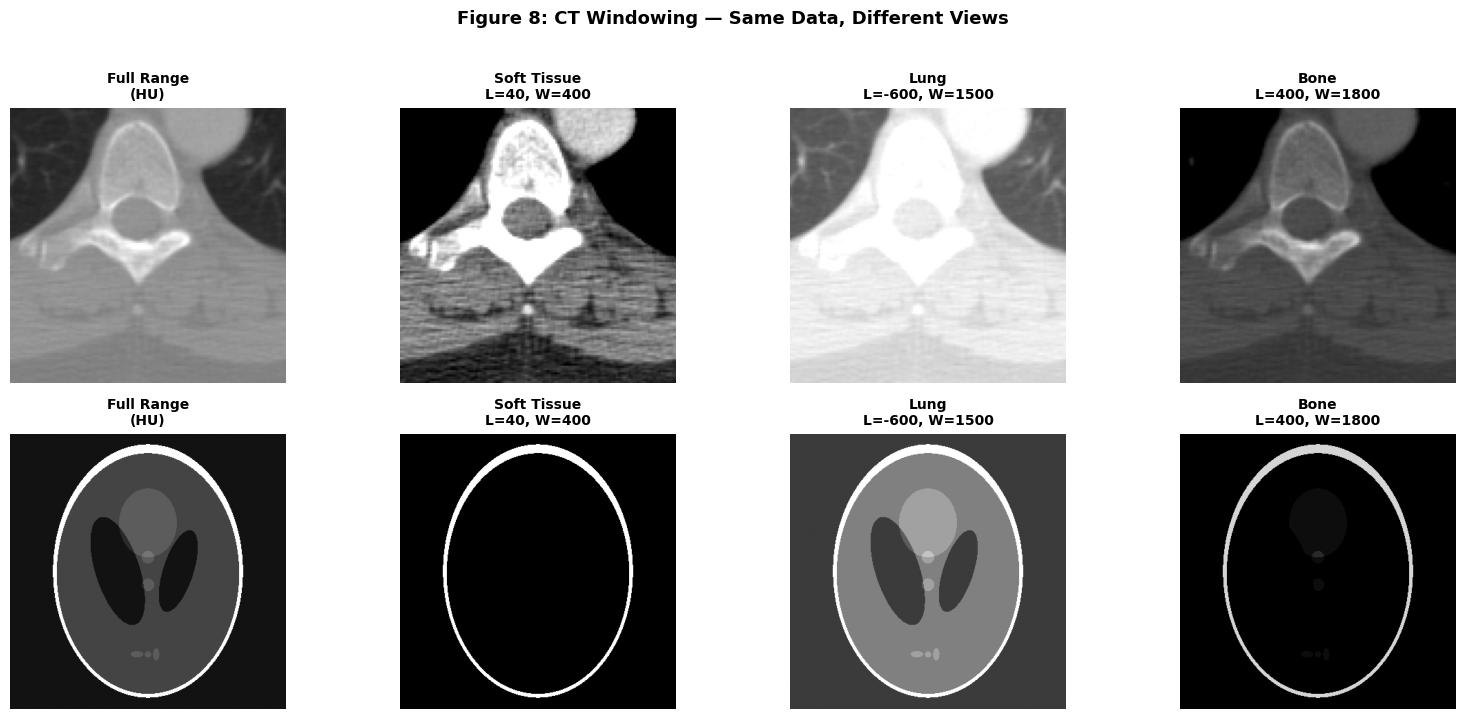

CT stored-value range: 128.0 to 2191.0
CT HU range: -896.0 to 1167.0
Using RescaleSlope=1.0, RescaleIntercept=-1024.0


In [16]:
# Figure 8: CT Windowing — real DICOM + phantom (FIXED)
import numpy as np
import matplotlib.pyplot as plt

def apply_window(image_hu, center, width):
    lower = center - width / 2
    upper = center + width / 2
    return np.clip((image_hu - lower) / (upper - lower), 0, 1)

# Convert stored DICOM values to Hounsfield Units
slope = float(getattr(ct_dcm, "RescaleSlope", 1.0))
intercept = float(getattr(ct_dcm, "RescaleIntercept", 0.0))
ct_hu = ct_pixels * slope + intercept

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

windows = [
    ("Full Range\n(HU)", ct_hu.mean(), ct_hu.max() - ct_hu.min()),
    ("Soft Tissue\nL=40, W=400", 40, 400),
    ("Lung\nL=-600, W=1500", -600, 1500),
    ("Bone\nL=400, W=1800", 400, 1800),
]

# Row 1: Real CT DICOM in HU
for ax, (title, c, w) in zip(axes[0], windows):
    ax.imshow(apply_window(ct_hu, c, w), cmap="gray", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.axis("off")
axes[0][0].set_ylabel("Real CT\n(HU-corrected)", fontsize=11, fontweight="bold")

# Row 2: Shepp-Logan phantom (synthetic, mapped to HU-like range)
hu_phantom = phantom * 2000 - 1000
for ax, (title, c, w) in zip(axes[1], windows):
    ax.imshow(apply_window(hu_phantom, c, w), cmap="gray", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.axis("off")
axes[1][0].set_ylabel("Phantom\n(synthetic)", fontsize=11, fontweight="bold")

plt.suptitle("Figure 8: CT Windowing — Same Data, Different Views",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}fig8_ct_windowing_real.pdf", bbox_inches="tight", dpi=150)
plt.savefig(f"{FIGURE_DIR}fig8_ct_windowing_real.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"CT stored-value range: {ct_pixels.min():.1f} to {ct_pixels.max():.1f}")
print(f"CT HU range: {ct_hu.min():.1f} to {ct_hu.max():.1f}")
print(f"Using RescaleSlope={slope}, RescaleIntercept={intercept}")

---

## DICOM Deep Dive

Explore all metadata fields in the real CT and MR DICOM files.

In [ ]:
fields = ['Modality', 'Manufacturer', 'PatientPosition', 'PixelSpacing',
         'SliceThickness', 'Rows', 'Columns', 'BitsStored',
         'RescaleIntercept', 'RescaleSlope', 'WindowCenter', 'WindowWidth']

for name, ds in [("CT (GE MEDICAL SYSTEMS)", ct_dcm), ("MR (TOSHIBA_MEC)", mr_dcm)]:
    print(f"{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    for field in fields:
        val = getattr(ds, field, 'N/A')
        if val != 'N/A':
            print(f"  {field:25s} = {val}")
    print()

print("In a real pipeline, you MUST check PixelSpacing, RescaleSlope/Intercept,")
print("and WindowCenter/Width before feeding images to a model.")

CT (GE MEDICAL SYSTEMS)
  Modality                  = CT
  Manufacturer              = GE MEDICAL SYSTEMS
  PatientPosition           = FFS
  PixelSpacing              = [0.661468, 0.661468]
  SliceThickness            = 5.000000
  Rows                      = 128
  Columns                   = 128
  BitsStored                = 16
  RescaleIntercept          = -1024
  RescaleSlope              = 1

MR (TOSHIBA_MEC)
  Modality                  = MR
  Manufacturer              = TOSHIBA_MEC
  PatientPosition           = HFS
  PixelSpacing              = [0.3125, 0.3125]
  SliceThickness            = 0.8000
  Rows                      = 64
  Columns                   = 64
  BitsStored                = 16
  WindowCenter              = 600
  WindowWidth               = 1600

In a real pipeline, you MUST check PixelSpacing, RescaleSlope/Intercept,
and WindowCenter/Width before feeding images to a model.


---

## Label Distribution (if MedMNIST available)

Chest X-ray datasets exhibit extreme class imbalance and multi-label structure.

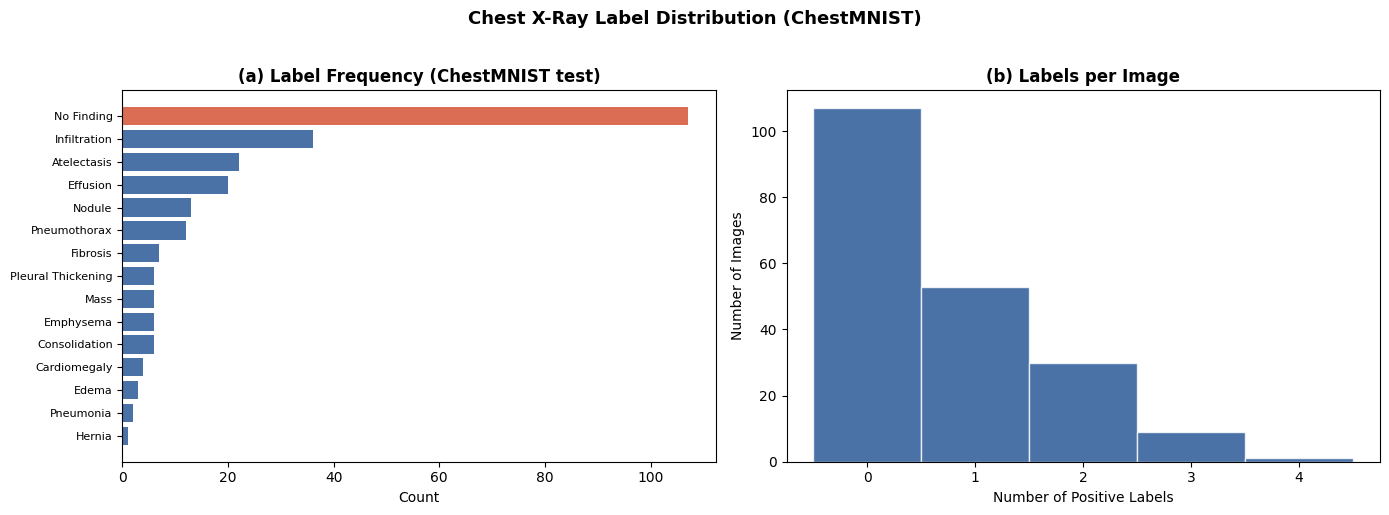

In [ ]:
if MEDMNIST_LOADED and chest_labels is not None:
    PATHOLOGY_NAMES = [
        "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
        "Mass", "Nodule", "Pneumonia", "Pneumothorax",
        "Consolidation", "Edema", "Emphysema", "Fibrosis",
        "Pleural Thickening", "Hernia"
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # (a) Label frequency
    ax = axes[0]
    label_counts = chest_labels.sum(axis=0).flatten()
    no_finding = (chest_labels.sum(axis=1) == 0).sum()

    names = PATHOLOGY_NAMES + ["No Finding"]
    counts = list(label_counts) + [no_finding]
    sort_idx = np.argsort(counts)[::-1]

    colors_bar = ["#D2492A" if names[i] == "No Finding" else "#1D4F91" for i in sort_idx]
    ax.barh(range(len(names)), [counts[i] for i in sort_idx], color=colors_bar, alpha=0.8)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels([names[i] for i in sort_idx], fontsize=8)
    ax.set_xlabel("Count")
    ax.set_title("(a) Label Frequency (ChestMNIST test)", fontweight="bold")
    ax.invert_yaxis()

    # (b) Labels per image
    ax = axes[1]
    n_per = chest_labels.sum(axis=1).flatten()
    bins = np.arange(-0.5, max(n_per) + 1.5, 1)
    ax.hist(n_per, bins=bins, color="#1D4F91", alpha=0.8, edgecolor="white")
    ax.set_xlabel("Number of Positive Labels")
    ax.set_ylabel("Number of Images")
    ax.set_title("(b) Labels per Image", fontweight="bold")

    plt.suptitle("Chest X-Ray Label Distribution (ChestMNIST)", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(f"{FIGURE_DIR}fig7_label_distribution.pdf", bbox_inches="tight", dpi=150)
    plt.savefig(f"{FIGURE_DIR}fig7_label_distribution.png", bbox_inches="tight", dpi=150)
    plt.show()
else:
    print("MedMNIST not loaded — skipping label distribution figure.")
    print("With ChestMNIST, this would show extreme class imbalance")
    print("('No Finding' dominates) and multi-label co-occurrence.")

---

## Discussion Questions

1. **DICOM metadata:** The CT and MRI above come from different manufacturers with different pixel spacings. If you trained on GE CT (0.66 mm/px) and tested on Siemens CT (0.49 mm/px), what would go wrong? How would you normalize?

2. **Windowing as feature engineering:** The lung window reveals structures invisible in the bone window. If your model needs to detect *both* lung nodules and rib fractures, what input strategy would you use?

3. **Augmentation by modality:** Compare the retinal augmentation results to what you'd expect for chest X-rays. Which augmentations transfer? Which are modality-specific?

4. **Label granularity:** ChestMNIST has image-level multi-labels. What would you need for a detection model (finding the nodule's location)? How much more expensive is that?

5. **Data access:** Why does this notebook use MedMNIST's downsampled images rather than full-resolution clinical data? What does that tell you about imaging data accessibility?

---

## Extending with Additional Datasets

**If MedMNIST download failed**, download `.npz` files manually:
- ChestMNIST: https://zenodo.org/records/10519652/files/chestmnist_224.npz
- DermaMNIST: https://zenodo.org/records/10519652/files/dermamnist_224.npz
- PathMNIST: https://zenodo.org/records/10519652/files/pathmnist_224.npz

Place in `./medmnist_data/` and re-run.

**For full-resolution clinical data** (requires credentialing):
- NIH ChestX-ray14: https://nihcc.app.box.com/v/ChestXray-NIHCC
- CheXpert (Stanford): https://stanfordmlgroup.github.io/competitions/chexpert/
- MIMIC-CXR (PhysioNet): https://physionet.org/content/mimic-cxr/
- ISIC Dermoscopy: https://www.isic-archive.com/
- TCGA Pathology WSIs: https://portal.gdc.cancer.gov/

---

## Summary

This notebook used real medical images from multiple sources. Key takeaways:

1. **Different modalities have fundamentally different intensity distributions** — normalization must be modality-aware
2. **DICOM metadata** (pixel spacing, manufacturer, window settings) directly affects model performance
3. **CT windowing** is a preprocessing choice that determines what your model can detect
4. **Augmentations must respect physics** — validity depends on the modality
5. **Label structure** (image-level, study-level, pixel-level) determines what tasks are feasible

**Next:** Thursday's lecture (L22) — transfer learning, U-Net, MIL, foundation models.